### Code to combine and generate the PCA plots for all the 7 clustering dimensions

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PowerTransformer
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")


In [3]:

TITLE_KW = dict(fontsize=20, fontweight='bold')
XLABEL_KW = dict(fontsize=16)
YLABEL_KW = dict(fontsize=16)
LEGEND_KW = dict(fontsize=13, title_fontsize=13)
PALETTE = "tab10"
LEGEND_LOC = 'upper right'
LEGEND_BBOX = (1.02, 1)


In [4]:

def paint(ax, title, xlabel, ylabel):
    ax.set_title(title, **TITLE_KW)
    ax.set_xlabel(xlabel, **XLABEL_KW)
    ax.set_ylabel(ylabel, **YLABEL_KW)
    ax.grid(True, linestyle='--', alpha=0.3)


In [5]:

def place_uniform_legend(ax, title):
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(title=title, bbox_to_anchor=LEGEND_BBOX, loc=LEGEND_LOC, **LEGEND_KW)
    else:
        ax.legend([], [], bbox_to_anchor=LEGEND_BBOX, loc=LEGEND_LOC)


In [6]:

def plot_pca_sonic_clusters(ax):
    try:
        AUDIO_FEATURES = ['Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Valence']
        df = pd.read_csv(r'..\data\processed\song_master_table_with_clusters.csv')
        X = df[AUDIO_FEATURES].fillna(0)
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_scaled)
        pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
        pca_df['Sonic_Cluster'] = df['Sonic_Cluster'].astype('category')
        sns.scatterplot(ax=ax, data=pca_df, x='PC1', y='PC2', hue='Sonic_Cluster', palette=PALETTE, alpha=0.7, s=30)
        paint(ax, 'Sonic DNA Clusters (PCA)', 'Principal Component 1', 'Principal Component 2')
        place_uniform_legend(ax, 'Sonic Cluster')
    except Exception as e:
        ax.set_title(f'Error: {e}', **TITLE_KW)
        ax.axis('off')


In [7]:

def plot_pca_artist_tiers(ax):
    try:
        FILE_PATH = r'..\data\processed\artist_master_table_with_clusters.csv'
        CLUSTER_COL = 'Artist_Tier'
        FEATURES = ['total_chart_appearances', 'average_rank', 'best_rank', 'career_length_days', 'top_50_rate']
        CLUSTER_NAMES = {0:"Rising Stars", 1:"Hit-Makers", 2:"Fringe", 3:"Superstars", 4:"Niche"}
        df = pd.read_csv(FILE_PATH).dropna(subset=FEATURES + [CLUSTER_COL])
        df['Cluster_Name'] = df[CLUSTER_COL].map(CLUSTER_NAMES).fillna(df[CLUSTER_COL])
        pt = PowerTransformer()
        X_scaled = pt.fit_transform(df[FEATURES])
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_scaled)
        df['PC1'], df['PC2'] = X_pca[:,0], X_pca[:,1]
        sns.scatterplot(ax=ax, data=df, x='PC1', y='PC2', hue='Cluster_Name', palette=PALETTE, s=30, alpha=0.7)
        paint(ax, 'Artist Success Tier (PCA)', 'PC1', 'PC2')
        place_uniform_legend(ax, 'Tier')
    except Exception as e:
        ax.set_title(f'Error: {e}', **TITLE_KW)
        ax.axis('off')


In [8]:

def plot_pca_temporal_clusters(ax):
    try:
        FEATURES = ['Year','Month_Sin','Month_Cos','DayOfWeek_Sin','DayOfWeek_Cos','IsWeekend','Quarter','Chart_Weeks','Days_In_Charts','Weeks_Per_Day_Ratio','Quick_Peak_Score','Season_Fall','Season_Spring','Season_Summer','Season_Winter']
        df = pd.read_csv(r'..\data\processed\temporal_features_with_clusters.csv')
        X = df[FEATURES].replace([np.inf, -np.inf], np.nan).fillna(df[FEATURES].median())
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_scaled)
        df['PC1'], df['PC2'] = X_pca[:,0], X_pca[:,1]
        sns.scatterplot(ax=ax, data=df, x='PC1', y='PC2', hue='Temporal_Cluster', palette=PALETTE, alpha=0.7, s=30)
        paint(ax, 'Temporal Clusters (PCA)', 'PC1', 'PC2')
        place_uniform_legend(ax, 'Cluster')
    except Exception as e:
        ax.set_title(f'Error: {e}', **TITLE_KW)
        ax.axis('off')


In [9]:

def plot_artist_feature_clusters(ax):
    try:
        artist_df = pd.read_csv(r'..\data\processed\artist_features_with_clusters.csv')
        X_train_scaled = pd.read_csv(r'..\data\processed\X_trained_artist.csv', index_col=0)
        pca = PCA(n_components=2)
        reduced = pca.fit_transform(X_train_scaled)
        artist_df['PC1'] = reduced[:, 0]
        artist_df['PC2'] = reduced[:, 1]
        feature_names = X_train_scaled.columns
        loadings = pd.DataFrame(pca.components_.T, columns=['PCA1', 'PCA2'], index=feature_names)
        top_pca1 = loadings['PCA1'].abs().idxmax()
        top_pca2 = loadings['PCA2'].abs().idxmax()

        sns.scatterplot(
            ax=ax,
            data=artist_df,
            x='PC1', y='PC2',
            hue='cluster_label', palette=PALETTE, s=30, alpha=0.8
        )
        paint(ax, "Artist Collaboration Clusters (PCA)", f"PCA 1 (Top: {top_pca1})", f"PCA 2 (Top: {top_pca2})")
        place_uniform_legend(ax, "Cluster")
    except Exception as e:
        ax.set_title(f'Error: {e}', **TITLE_KW)
        ax.axis('off')


In [10]:

def plot_pca_geographic_clusters(ax):
    try:
        geo_features = ['num_nationalities','num_continents','international_collab','geographic_diversity_score','points_from_international','western_dominance']
        df = pd.read_csv(r'..\data\processed\songs_train_with_clusters.csv')
        X = df[geo_features].fillna(0)
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_scaled)
        df['PC1'], df['PC2'] = X_pca[:,0], X_pca[:,1]
        hue_col = 'cluster_label' if 'cluster_label' in df.columns else 'cluster'
        sns.scatterplot(ax=ax, data=df, x='PC1', y='PC2', hue=hue_col, palette=PALETTE, s=30, alpha=0.7)
        paint(ax, "Geographic Reach Clusters (PCA)", 'PC1', 'PC2')
        place_uniform_legend(ax, "Cluster")
    except Exception as e:
        ax.set_title(f'Error: {e}', **TITLE_KW)
        ax.axis('off')


In [11]:

def plot_pca_performance_clusters(ax):
    try:
        FEATURES = ['Best_Rank','Avg_Rank','Rank_Std','Chart_Weeks','Total_Points','Points_Per_Week','Top10_Rate','Top50_Rate','Rank_Range','Volatility_Score','Dominance_Score','Consistency_Score','Rank_Trajectory']
        df = pd.read_csv(r'..\data\processed\performance_features_with_clusters.csv')
        X = df[FEATURES].replace([np.inf, -np.inf], np.nan).fillna(df[FEATURES].median())
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_scaled)
        # Mirror PC1
        df['PC1'] = -X_pca[:,0]   # Flipped PC1
        df['PC2'] = X_pca[:,1]
        sns.scatterplot(ax=ax, data=df, x='PC1', y='PC2', hue='Performance_Cluster', palette=PALETTE, alpha=0.7, s=30)
        paint(ax, 'Performance Clusters (PCA)', 'PC1', 'PC2')
        place_uniform_legend(ax, 'Cluster')
    except Exception as e:
        ax.set_title(f'Error: {e}', **TITLE_KW)
        ax.axis('off')


In [12]:

def plot_audio_evolution_clusters(ax):
    try:
        df = pd.read_csv(r'..\data\processed\Audio_evolution_clustering.csv')
        df['Date'] = pd.to_datetime(df['Date'])
        df['Year'] = df['Date'].dt.year
        audio_features = ['Danceability', 'Energy', 'Valence']
        year_avg_features = df.groupby('Year')[audio_features].transform('mean')
        df_dev = df[audio_features].sub(year_avg_features)
        df_dev.columns = [f'{col}_dev' for col in audio_features]
        cluster_col = 'evolution_cluster_name' if 'evolution_cluster_name' in df.columns else 'cluster'
        df_temp = pd.concat([df[['id', cluster_col]], df_dev], axis=1)
        agg_dict = {col:'mean' for col in df_dev.columns}; agg_dict[cluster_col]='first'
        df_unique = df_temp.groupby('id').agg(agg_dict).reset_index()
        scaler = StandardScaler()
        X = df_unique[[c for c in df_unique.columns if '_dev' in c]]
        X_scaled = scaler.fit_transform(X)
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_scaled)
        df_unique['PC1'], df_unique['PC2'] = X_pca[:,0], X_pca[:,1]
        sns.scatterplot(ax=ax, data=df_unique, x='PC1', y='PC2', hue=cluster_col, palette=PALETTE, alpha=0.7, s=30)
        paint(ax, 'Sonic Evolution Clusters (PCA)', 'PC1', 'PC2')
        place_uniform_legend(ax, 'Cluster')
    except Exception as e:
        ax.set_title(f'Error: {e}', **TITLE_KW)
        ax.axis('off')


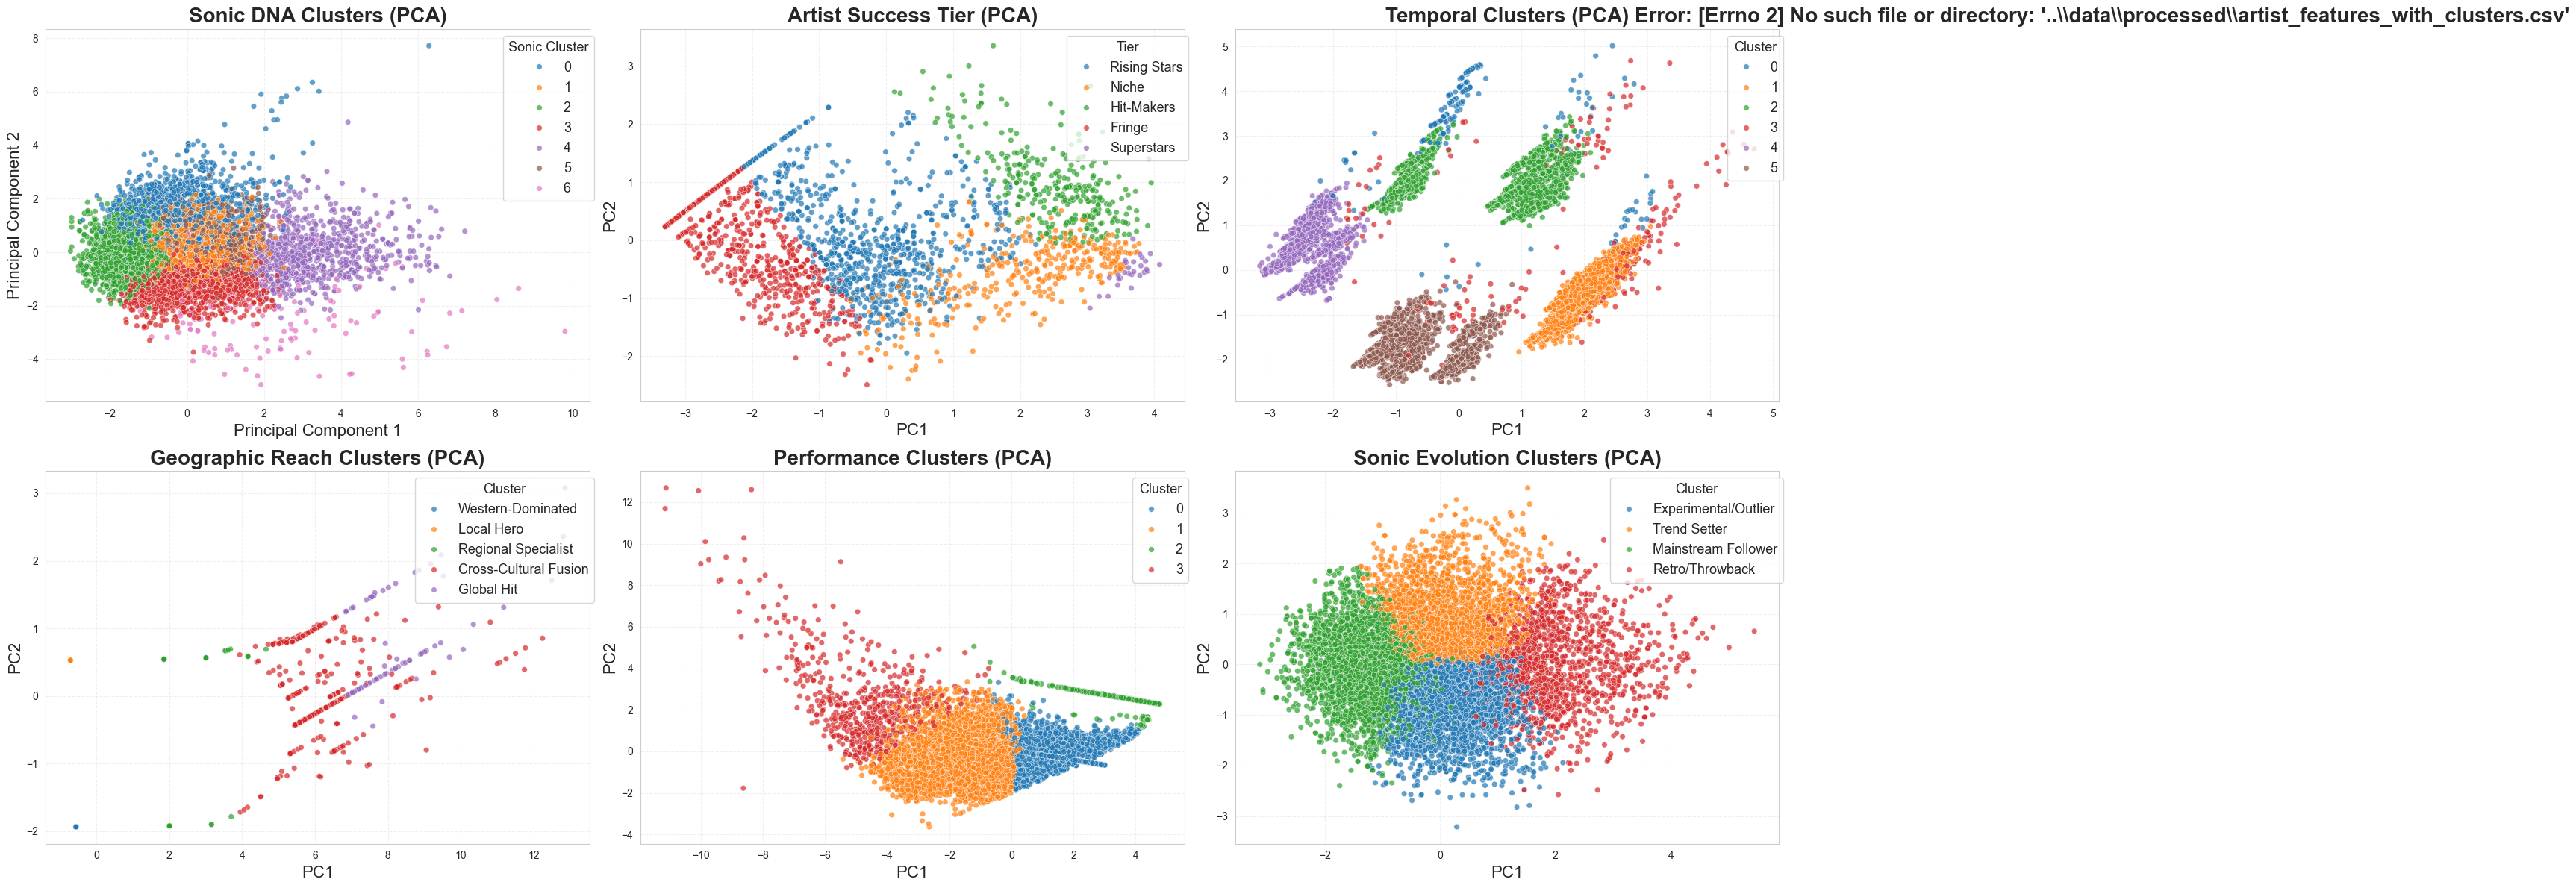

Saved combined figure to combined_pca_cluster_plots.svg


In [14]:

plotters_in_order = [
    plot_pca_sonic_clusters,       # 0
    plot_pca_artist_tiers,         # 1
    plot_pca_temporal_clusters,    # 2
    plot_artist_feature_clusters,  # 3
    plot_pca_geographic_clusters,  # 4
    plot_pca_performance_clusters, # 5 
    plot_audio_evolution_clusters  # 6
]

fig, axs = plt.subplots(2, 4, figsize=(32, 12))

# Top row: left to right
for i in range(4):
    plotters_in_order[i](axs[0, i])

# Bottom row: place in left 3 positions, leave rightmost empty
for i in range(3):
    plotters_in_order[4 + i](axs[1, i])

axs[1, 3].axis('off')

fig.tight_layout(rect=[0,0,1,1])
fig.savefig(r"..\outputs\figures\combined_pca_cluster_plots.svg", format="svg")
plt.show()
print("Saved combined figure to combined_pca_cluster_plots.svg")
